<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT2605: Cálculo Científico I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 06: Ecuaciones No Lineales</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Thomas F&uuml;hrer y Manuel A. Sánchez | <b>Fecha:</b> 15 de Mayo, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>

</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">🎯 Objetivos de la Sesión</h3>
    <ul>
        <li>M&eacute;todos de bisecci&oacute;n, secante, Newton</li>
        <li>Estudios de convergencia</li>
        <li>M&eacute;todo de Newton para sistemas de ecuaciones no lineales</li>
        <li>Cuencas de atracci&oacute;n</li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2e7d32; margin-top: 0;">👤 Identificación del Estudiante</h3>
    <p style="margin-bottom: 10px; color: #555;">Por favor, completa tus datos antes de comenzar:</p>
    <ul style="list-style-type: none; padding-left: 0; color: #333;">
        <li style="margin-bottom: 5px;"><b>📌 Nombre Completo:</b> _______________________________________</li>
        <li style="margin-bottom: 5px;"><b>📌 Rol / Nº Alumno:</b> _________________________</li>
    </ul>
    <p style="font-size: 0.85em; color: #2e7d32; margin-top: 15px; border-top: 1px solid #a5d6a7; padding-top: 5px;">
        <i>💡 Haz doble clic en esta celda para editarla con tus datos.</i>
    </p>
</div>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')      # Nombre antiguo

plt.rcParams['figure.figsize'] = (10, 6)

print(f"Versión de Numpy: {np.__version__}")
print(f"Estilo usado: {plt.style.context}")

Versión de Numpy: 2.4.4
Estilo usado: <function context at 0x7f8abb527320>


<div class="alert-block alert-warning "; style=" border-left: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría:</h3>
    <ul>
        <li>M&eacute;todo de bisecci&oacute;n: para $n=1,2,...$ repita <br>
            $x_n = \frac{a+b}2$ <br>
            si $f(a)f(x_n)<0$ entonces $b = x_n$ <br>
            o si  $f(x_n)f(b)<0$ entonces $a = x_n$
        </li>
        <li>M&eacute;todo de secante: $x_{n+1} = x_n - \frac{f(x_n)(x_n-x_{n-1})}{f(x_n)-f(x_{n-1})}$
        </li>
        <li>M&eacute;todo de Newton (o Newton--Rhapson): $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$
        </li>
        <li>M&eacute;todo de Newton en varias variables: $x^{(n+1)} = x^{(n)} - J_F(x^{(n)})^{-1}F(x^{(n)})$ <br>
            donde $J_F(x^{(n)})^{-1}$ denota la matriz Jacobiana de $F\colon \mathbb{R}^N\to \mathbb{R}^N$
        </li>
    </ul>
</div>

# Ecuaci&oacute;n no lineal
Comenzamos a definir los tres m&eacute;todos para encontrar la soluci&oacute;n de $f(x) = 0$

In [3]:
def bisection(f, a, b, tol=1e-8, max_iter=100):
    if f(a) * f(b) >= 0:
        return None  # abortar si no se puede asegurar existencia de raiz
    
    for i in range(max_iter):
        c = (a + b) / 2
        if abs(f(c)) < tol or (b - a) / 2 < tol:
            return c
        if f(c) * f(a) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2

In [4]:
def secant(f, x0, x1, tol=1e-8, max_iter=100):
    for i in range(max_iter):
        fx0 = f(x0)
        fx1 = f(x1)
        if abs(fx1 - fx0) < 1e-15: # evitar dividir por "zero"
            return x1
        
        x_next = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        
        if abs(x_next - x1) < tol:
            return x_next
        x0, x1 = x1, x_next
    return x1

In [5]:
def newton(f, df, x0, tol=1e-8, max_iter=100):
    xn = x0
    for i in range(max_iter):
        fxn = f(xn)
        dfxn = df(xn)
        if abs(dfxn)<1e-15:
            return None # chequear si derivada se anula
        
        xn_next = xn - fxn / dfxn
        
        if abs(xn_next - xn) < tol:
            return xn_next
        xn = xn_next
    return xn

## Ejemplos

### Ejemplo 1: 
$f(x) = x^2-2$

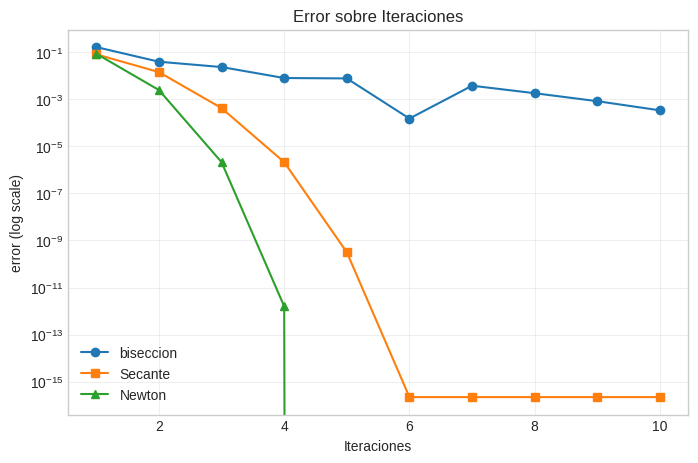

In [6]:
# Funcion: f(x) = x^2 - 2 (raiz es sqrt(2))
func = lambda x: x**2 - 2
dfunc = lambda x: 2*x
root_true = np.sqrt(2)

iterations = range(1, 11)
err_bisect = [abs(bisection(func, 1, 2, max_iter=i) - root_true) for i in iterations]
err_secant = [abs(secant(func, 1, 2, max_iter=i) - root_true) for i in iterations]
err_newton = [abs(newton(func, dfunc, 2, max_iter=i) - root_true) for i in iterations]

# --- PLOT ---
plt.figure(figsize=(8, 5))
plt.semilogy(iterations, err_bisect, 'o-', label='biseccion')
plt.semilogy(iterations, err_secant, 's-', label='Secante')
plt.semilogy(iterations, err_newton, '^-', label='Newton')

plt.title('Error sobre Iteraciones')
plt.xlabel('Iteraciones')
plt.ylabel('error (log scale)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

Tratamos de ver si es realmente convergencia cuadratica (Newton): $|x-x_n|\leq C |x-x_{n-1}|^2$

In [7]:
razon = [err_newton[j]/err_newton[j-1]**2 for j in range(1,4)]
print(razon)

[np.float64(0.33333333333333104), np.float64(0.35294117646827655), np.float64(0.3535223844872458)]


Parece que la constante es alrededor de 0.353

Si no se sabe de antemano el orden de convergencia, una posibilidad es la siguiente (orden experimental, ya vimos en Laboratorios anteriores):
Supongamos que $|x-x_n| = C |x-x_{n-1}|^\alpha$. Si aplicamos el logaritmo y usando $e_n = |x-x_n|$, veremos 
\begin{align*}
\log(e_n) &= \log(C) + \alpha \log(e_{n-1}), \\
\log(e_{n-1}) &= \log(C) + \alpha \log(e_{n-2}).
\end{align*}
Restando y resolviendo para $\alpha$ nos da el orden experimental. 

### Ejemplo 2
$f(x) = \sqrt[3]{x}$

In [8]:


# funcion: f(x) = x^(1/3)
f = lambda x: math.copysign(abs(x)**(1/3), x)
df = lambda x: (1/3) * (abs(x)**(-2/3))

# met. biseccion
print(f"Bisection resultado: {bisection(f, -0.666, 1)}") 

# met. Secante
print(f"Secant resultado: {secant(f, -0.666, 1)}")

# met. Newton-Rhapson
print(f"Newton resultado: {newton(f, df, 1)}")

Bisection resultado: 5.520880203211526e-09
Secant resultado: 0.7259000205436832
Newton resultado: None


De hecho, met. de Newton ni siquiera converge con $x_0$ cerca de $0$ (que es la ra&iacute;z)

In [9]:
print(f"Newton resultado: {newton(f, df, 0.00001)}")

Newton resultado: None


Para analizar este caso: calculamos $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)} = -2x_n$

Entonces, para cada valor inicial $x_0\neq 0$ nos alejamos de la ra&iacute;z real.
Nota que $f'(x)$ no est&aacute; definida para $x=0$. 

Podemos estudiar convergencia del m&eacute;todo de bisecci&oacute;n y secante:

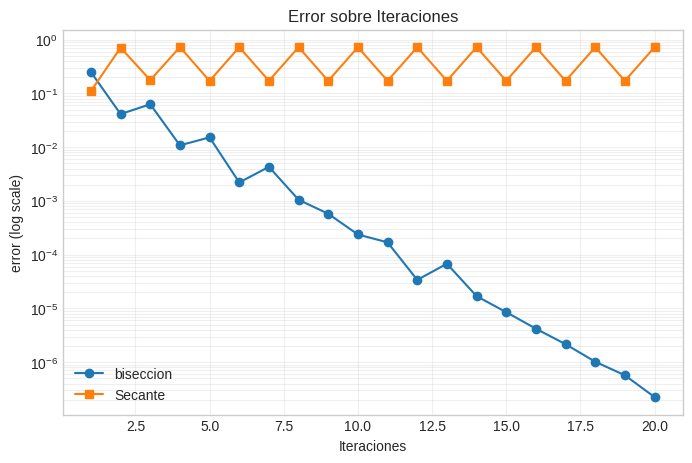

In [88]:
f = lambda x: math.copysign(abs(x)**(1/3), x)
root_true = 0

iterations = range(1, 21)
err_bisect = [abs(bisection(f, -0.666, 1, max_iter=i) - root_true) for i in iterations]
err_secant = [abs(secant(f, -0.666, 1, max_iter=i) - root_true) for i in iterations]

# --- PLOT ---
plt.figure(figsize=(8, 5))
plt.semilogy(iterations, err_bisect, 'o-', label='biseccion')
plt.semilogy(iterations, err_secant, 's-', label='Secante')

plt.title('Error sobre Iteraciones')
plt.xlabel('Iteraciones')
plt.ylabel('error (log scale)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

# Sistemas de ecuaciones no lineales

In [10]:
def newton_nd(f, jac, x0, tol=1e-8, max_iter=100):
    """
    Newton's method for n-dimensional systems.
    
    Parameters:
    f    : function that returns a 1D array (the system of equations)
    jac  : function that returns a 2D array (the Jacobian matrix)
    x0   : 1D array, the initial guess
    tol  : convergence tolerance
    """
    x = np.array(x0, dtype=float)
    
    for i in range(max_iter):
        F_val = f(x)
        J_val = jac(x)
        
        # Check if we have reached the root
        if np.linalg.norm(F_val, ord=2) < tol:
            return x
        
        # Solve J * delta_x = -F
        try:
            delta_x = np.linalg.solve(J_val, -F_val)
        except np.linalg.LinAlgError:
            print("Jacobian is singular. Method fails.")
            return None
            
        x = x + delta_x
        
        # Optional: check if the update itself is smaller than tolerance
        if np.linalg.norm(delta_x, ord=2) < tol:
            return x
            
    return x

Como ejemplo consideramos el sistema:
\begin{align*}
    x^2 + y^2 -4 &= 0, \\
e^x + y -1 &= 0.
\end{align*}
con vector inicial $\begin{pmatrix} 1\\-1\end{pmatrix}$

In [11]:

# Solving the system:
# x^2 + y^2 - 4 = 0
# exp(x) + y - 1 = 0

def system(x_vec):
    x, y = x_vec
    return np.array([
        x**2 + y**2 - 4,
        np.exp(x) + y - 1
    ])

def jacobian(x_vec):
    x, y = x_vec
    return np.array([
        [2*x, 2*y],
        [np.exp(x), 1]
    ])

guess = [1.0, -1.0]
root = newton_nd(system, jacobian, guess)
print(f"Raiz: {root}")

Raiz: [ 1.00416874 -1.72963729]


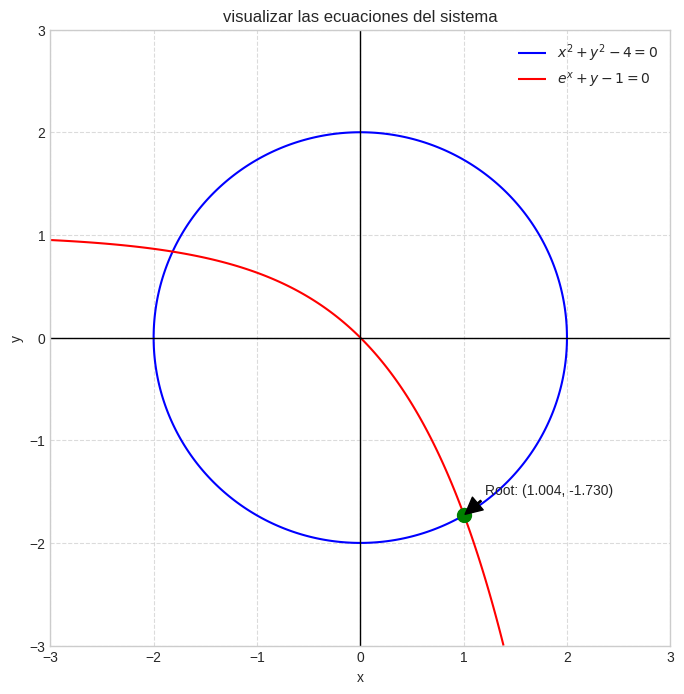

In [12]:
# Define the system again for the plot
def f1(x, y): return x**2 + y**2 - 4
def f2(x, y): return np.exp(x) + y - 1

# Create a grid of points
x_range = np.linspace(-3, 3, 400)
y_range = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x_range, y_range)

# Calculate Z values for contour lines (where f(x,y) = 0)
Z1 = f1(X, Y)
Z2 = f2(X, Y)

plt.figure(figsize=(8, 8))

# Plot the equations as contours at level 0
cp1 = plt.contour(X, Y, Z1, levels=[0], colors='blue')
cp2 = plt.contour(X, Y, Z2, levels=[0], colors='red')

# legend
h1, _ = cp1.legend_elements()
h2, _ = cp2.legend_elements()
plt.legend([h1[0], h2[0]], ["$x^2 + y^2 - 4 = 0$", "$e^x + y - 1 = 0$"])

# Mark the root we found in the previous step
# Root found was approx: [1.004, -1.729]
root_x, root_y = 1.00416874, -1.7297371
plt.plot(root_x, root_y, 'go', markersize=10, label='raiz')
plt.annotate(f'Root: ({root_x:.3f}, {root_y:.3f})', 
             xy=(root_x, root_y), xytext=(root_x+0.2, root_y+0.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.title("visualizar las ecuaciones del sistema")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.show()

De la visualizaci&oacute;n vemos que hay otra ra&iacute;z. Para encontrarla podemos eligir un vector inicial cerca de este punto, por ejemplo $\begin{pmatrix}-2\\1\end{pmatrix}$guess = [1.0, -1.0]


In [13]:
guess = [-2.0, 1.0]
root = newton_nd(system, jacobian, guess)
print(f"Raiz: {root}")

Raiz: [-1.81626407  0.8373678 ]


Tal vez no converge el m&eacute;todo:

In [14]:
guess = [0.0,0.0]
root = newton_nd(system, jacobian, guess)
print(f"Raiz: {root}")

Jacobian is singular. Method fails.
Raiz: None


De hecho podemos vizualizar para que vectores iniciales el m&eacute;todo de Newton converge a la raiz $\begin{pmatrix}1.00416874\\-1.72963729\end{pmatrix}$ o a la otra.

/usr/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/tmp/ipykernel_71347/536287125.py:21: RuntimeWarning: overflow encountered in exp
  return np.array([x**2 + y**2 - 4, np.exp(x) + y - 1])
/tmp/ipykernel_71347/536287125.py:25: RuntimeWarning: overflow encountered in exp
  return np.array([[2*x, 2*y], [np.exp(x), 1]])


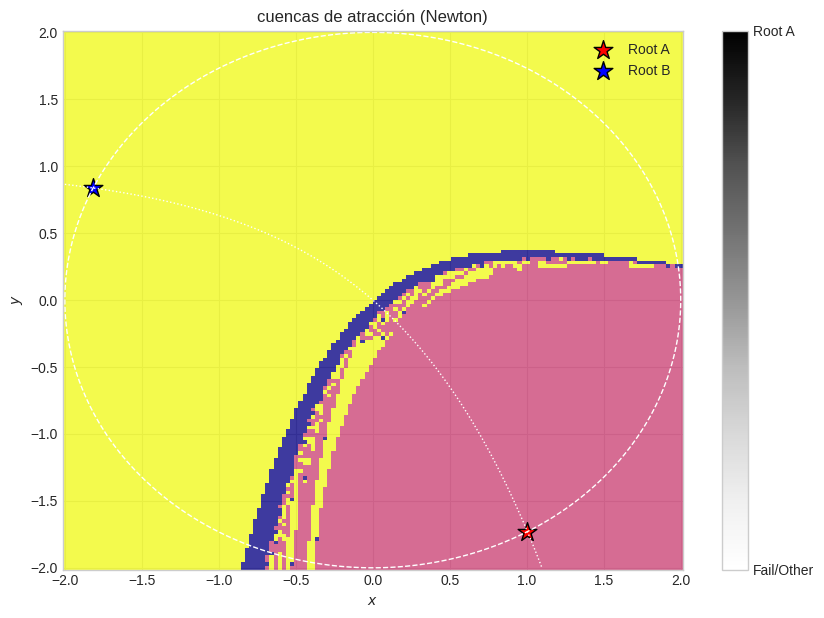

In [15]:
# --- 1. Use the previously defined function ---
def newton_nd(f, jac, x0, tol=1e-8, max_iter=100):
    x = np.array(x0, dtype=float)
    for i in range(max_iter):
        F_val = f(x)
        J_val = jac(x)
        if np.linalg.norm(F_val, ord=2) < tol:
            return x
        try:
            delta_x = np.linalg.solve(J_val, -F_val)
        except np.linalg.LinAlgError:
            return None # Singular Jacobian
        x = x + delta_x
        if np.linalg.norm(delta_x, ord=2) < tol:
            return x
    return None # Did not converge

# --- 2. System definition ---
def system(x_vec):
    x, y = x_vec
    return np.array([x**2 + y**2 - 4, np.exp(x) + y - 1])

def jacobian(x_vec):
    x, y = x_vec
    return np.array([[2*x, 2*y], [np.exp(x), 1]])

# Known roots found by previous execution
root_a = np.array([1.00416874, -1.7297371])
root_b = np.array([-1.81626407, 0.8373678])

# --- 3. Grid Generation and Convergence Test ---
res = 150 # Resolution of the map
x_coords = np.linspace(-2, 2, res)
y_coords = np.linspace(-2, 2, res)
X, Y = np.meshgrid(x_coords, y_coords)
Z = np.zeros_like(X)

for i in range(res):
    for j in range(res):
        start_guess = [X[i, j], Y[i, j]]
        result = newton_nd(system, jacobian, start_guess, max_iter=20)
        
        if result is None:
            Z[i, j] = 0 # Failed
        elif np.linalg.norm(result - root_a) < 1e-3:
            Z[i, j] = 1 # Convergence to Root A
        elif np.linalg.norm(result - root_b) < 1e-3:
            Z[i, j] = 2 # Convergence to Root B
        else:
            Z[i, j] = 0 # Converged elsewhere or unknown

# --- 4. Plotting ---
plt.figure(figsize=(10, 7))
# Use 'nearest' shading to show the pixels clearly
plt.pcolormesh(X, Y, Z, cmap='plasma', shading='nearest', alpha=0.8)

# Overlay the equations for context
x_fine = np.linspace(-2, 2, 800)
y_fine = np.linspace(-2, 2, 800)
Xf, Yf = np.meshgrid(x_fine, y_fine)
plt.contour(Xf, Yf, Xf**2 + Yf**2 - 4, levels=[0], colors='white', linestyles='dashed', linewidths=1)
plt.contour(Xf, Yf, np.exp(Xf) + Yf - 1, levels=[0], colors='white', linestyles='dotted', linewidths=1)

# Plot the root locations
plt.scatter(root_a[0], root_a[1], color='red', marker='*', s=200, edgecolors='black', label='Root A')
plt.scatter(root_b[0], root_b[1], color='blue', marker='*', s=200, edgecolors='black', label='Root B')

plt.title("cuencas de atracción (Newton)")
plt.xlabel("$x$")
plt.ylabel("$y$")
cbar = plt.colorbar(ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Fail/Other', 'Root A', 'Root B'])
plt.legend(facecolor='lightgrey')
plt.show()

---
<div class="alert alert-block alert-success"> 

## Evaluaci&oacute;n:

</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 1:</h3>
    Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [ ]:
a = np.array([0.9,0.80985,0.656])
b = np.array([0.5231,0.3505,0.1833])

# Espacio para tu codigo:


<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 2:</h3>
Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [ ]:
# Espacio para tu codigo:



<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 3: </h3>
    Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [ ]:
# Espacio para tu codigo:


